# Claim Denial Prediction — Modeling & Scoring

**Part 1** Train a binary classifier on `claims_history.csv` (using the provided `split`),
choose a threshold driven by the *"review team can only inspect the top 25% by risk"* constraint,
and score `current_claims.csv`.

**Part 2** Generate short, plain-English explanations for the top-10 highest-risk current claims.

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    precision_score, recall_score, f1_score, confusion_matrix,
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

In [3]:
# ---- Paths ----------------------------------------------------------------
root_path = Path(r'C:\Users\shiva\Desktop\Ensemble_Partner_Hiring_Assignment\Hiring Assessment - AI Team - Classical ML + Gen AI problem (ML + basic Gen AI) (1)\Hiring Assessment - AI Team - Classical ML + Gen AI problem')
data_path = root_path / 'data'

hist = pd.read_csv(data_path / 'claims_history.csv')
curr = pd.read_csv(data_path / 'current_claims.csv')
print('history:', hist.shape, '| current:', curr.shape)

history: (3200, 20) | current: (500, 17)


## 1. Feature engineering

One function applied to **both** datasets so the current claims get exactly the
same columns. The two engineered "gap" flags encode the real risk pattern
(*required but not on file*), matching the denial reasons in the data.

**Leakage variables:** `is_denied`, `denial_reason`, and `split` are never used as inputs.

In [4]:
TARGET = 'is_denied'
ID_COL = 'claim_id'

CATEGORICAL = ['payer_id', 'payer_type', 'visit_type']
BINARY_FLAGS = [
    'prior_auth_required', 'has_prior_auth', 'is_in_network',
    'missing_documentation_flag', 'eligibility_verified',
    'referral_required', 'referral_present',
]
NUMERIC = ['total_billed', 'expected_payment', 'num_procedures',
           'num_diagnoses', 'days_to_submit']
ENGINEERED = ['prior_auth_gap', 'referral_gap', 'payment_ratio', 'log_total_billed']

FEATURES = CATEGORICAL + BINARY_FLAGS + NUMERIC + ENGINEERED


def engineer(df):
    df = df.copy()
    # Risk gaps.
    df['prior_auth_gap'] = ((df['prior_auth_required'] == 1) & (df['has_prior_auth'] == 0)).astype(int)
    df['referral_gap']   = ((df['referral_required'] == 1) & (df['referral_present'] == 0)).astype(int)
    # Contractual context.
    df['payment_ratio']    = df['expected_payment'] / df['total_billed'].replace(0, np.nan)
    df['payment_ratio']    = df['payment_ratio'].fillna(0)
    df['log_total_billed'] = np.log1p(df['total_billed'])
    return df


hist_e = engineer(hist)
curr_e = engineer(curr)
hist_e[ENGINEERED].describe()

,prior_auth_gap,referral_gap,payment_ratio,log_total_billed
count,3200.000000,3200.000000,3200.000000,3200.000000
mean,0.096875,0.081562,0.496037,9.006436
std,0.295834,0.273740,0.111637,0.884712
min,0.000000,0.000000,0.180000,6.260785
25%,0.000000,0.000000,0.405621,8.389834
50%,0.000000,0.000000,0.502985,8.983878
75%,0.000000,0.000000,0.582374,9.605634
max,1.000000,1.000000,0.820001,11.461643


## 2. Use the provided split

The `split` column is used **as-is** — no custom resampling.

In [5]:
train = hist_e[hist_e['split'] == 'train']
val   = hist_e[hist_e['split'] == 'validation']
test  = hist_e[hist_e['split'] == 'test']

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

for name, y in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f'{name:5s} n={len(y):4d}  denial_rate={y.mean():.3f}')

train n=2122  denial_rate=0.211
val   n= 539  denial_rate=0.191
test  n= 539  denial_rate=0.260


# 3. Preprocessing + Baseline model

In [6]:
def capture_at_top_k(y_true, scores, k=0.25):
    # Fraction of all positives captured in the top-k fraction by score,
    # plus the precision within that reviewed slice.
    y_true = np.asarray(y_true)
    n_review = max(1, int(np.ceil(len(scores) * k)))
    order = np.argsort(scores)[::-1]
    top = order[:n_review]
    captured = y_true[top].sum()
    total_pos = y_true.sum()
    return {
        'reviewed': n_review,
        'recall_at_25': captured / total_pos if total_pos else 0.0,
        'precision_at_25': captured / n_review,
    }


from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="prior", random_state=42)
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_val)
capture_at_top_k(y_val, y_pred, 0.25)


{'reviewed': 135,
 'recall_at_25': 0.2815533980582524,
 'precision_at_25': 0.21481481481481482}

## AutoML sanity check (FLAML)

In [7]:
!pip install "flaml[automl]"

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from flaml import AutoML

# preprocessing (encoding, scaling) internally.
def as_flaml(X):
    X = X[FEATURES].copy()
    for c in CATEGORICAL:
        X[c] = X[c].astype('category')
    return X

Xtr_f, Xval_f, Xte_f = as_flaml(X_train), as_flaml(X_val), as_flaml(X_test)

# Custom metric in FLAML's signature. FLAML MINIMISES, so we return
# (1 - recall@25%) as the loss; the dict is just for logging.
def flaml_recall_at_top25(X_val, y_val, estimator, labels,
                          X_train, y_train, weight_val=None, weight_train=None, *args):
    y_score = estimator.predict_proba(X_val)[:, 1]
    n_review = max(1, int(np.ceil(len(y_score) * 0.25)))
    top = np.argsort(y_score)[::-1][:n_review]
    yv = np.asarray(y_val)
    recall = yv[top].sum() / yv.sum() if yv.sum() else 0.0
    return 1 - recall, {"recall_at_top25": recall}

automl = AutoML()
automl.fit(
    X_train=Xtr_f, y_train=y_train.to_numpy(),
    task="classification",
    metric=flaml_recall_at_top25,
    estimator_list=["lgbm", "xgboost", "rf", "extra_tree", "lrl1", "lrl2"],
    eval_method="holdout",
    X_val=Xval_f, y_val=y_val.to_numpy(),
    time_budget=60,          # seconds; bump up for a longer search
    seed=RANDOM_STATE,
    verbose=1,
)

print("\nFLAML best estimator :", automl.best_estimator)
print("FLAML best config    :", automl.best_config)

# Score FLAML on val + test with the same operating-point metric as everything else.
print("\nFLAML operating-point metrics:")
for split_name, Xs, ys in [("val", Xval_f, y_val), ("test", Xte_f, y_test)]:
    s = automl.predict_proba(Xs)[:, 1]
    cap = capture_at_top_k(ys, s, 0.25)
    print(f"  {split_name:4s}  recall@25%={cap['recall_at_25']:.3f}  "
          f"precision@25%={cap['precision_at_25']:.3f}  "
          f"pr_auc={average_precision_score(ys, s):.3f}")


FLAML best estimator : rf
FLAML best config    : {'n_estimators': 4, 'max_features': 0.26364792307871493, 'max_leaves': 8, 'criterion': 'gini'}

FLAML operating-point metrics:
  val   recall@25%=0.534  precision@25%=0.407  pr_auc=0.393
  test  recall@25%=0.407  precision@25%=0.422  pr_auc=0.411


## 4. Pickup XGboost and hyperparameter tune

In [ ]:
from sklearn.model_selection import ParameterSampler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

_pos = y_train.mean()
SCALE_POS_WEIGHT = (1.0 - _pos) / _pos

xgb_preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
    ('num', StandardScaler(), NUMERIC + ENGINEERED),
    ('flag', 'passthrough', BINARY_FLAGS),
])


# ---- Custom early-stopping metric: recall within the top-25% by score -------
# XGBoost's sklearn wrapper MINIMISES the custom eval_metric, so we return the
# loss form (1 - recall@25%). recall@25% depends only on the RANKING of scores,
def recall_at_25_loss(y_true, y_pred):
    y_true = np.asarray(y_true)
    n_review = max(1, int(np.ceil(len(y_pred) * 0.25)))
    top = np.argsort(y_pred)[::-1][:n_review]
    total_pos = y_true.sum()
    recall = y_true[top].sum() / total_pos if total_pos else 0.0
    return 1.0 - recall


# Randomised search over a broad, regularisation-aware space (small dataset).
# n_estimators is now an UPPER CAP -- early stopping trims to the best iteration.
XGB_SPACE = {
    'clf__n_estimators':     [1000],
    'clf__max_depth':        [2, 3, 4, 5],
    'clf__learning_rate':    [0.01, 0.02, 0.03, 0.05, 0.1],
    'clf__subsample':        [0.7, 0.8, 0.9, 1.0],
    'clf__colsample_bytree': [0.6, 0.8, 1.0],
    'clf__min_child_weight': [1, 3, 5],
    'clf__gamma':            [0, 0.5, 1.0],
    'clf__reg_alpha':        [0, 0.1, 1.0],
    'clf__reg_lambda':       [1.0, 3.0, 5.0],
}
XGB_N_ITER = 80
EARLY_STOP = 50


def make_xgb_clf(**p):
    return XGBClassifier(
        eval_metric=recall_at_25_loss, scale_pos_weight=SCALE_POS_WEIGHT,
        tree_method='hist', n_jobs=-1, random_state=RANDOM_STATE,
        early_stopping_rounds=EARLY_STOP, **p)


# Fit the preprocessor ONCE (independent of hyperparams) so we can hand XGBoost a
# preprocess eval_set for you.
_prep = xgb_preprocess.fit(X_train, y_train)
_Xtr_t = _prep.transform(X_train)
_Xval_t = _prep.transform(X_val)

_candidates = list(ParameterSampler(XGB_SPACE, n_iter=XGB_N_ITER, random_state=RANDOM_STATE))
_best = (-1.0, -1.0)
xgb_best_pipe, xgb_best_params = None, None
for _params in _candidates:
    _p = {k.replace('clf__', ''): v for k, v in _params.items()}
    _clf = make_xgb_clf(**_p)
    _clf.fit(_Xtr_t, y_train, eval_set=[(_Xval_t, y_val)], verbose=False)
    _s = _clf.predict_proba(_Xval_t)[:, 1]   # uses best_iteration automatically
    _score = (capture_at_top_k(y_val, _s, 0.25)['recall_at_25'],
              average_precision_score(y_val, _s))
    if _score > _best:
        # Store as a ready-to-use pipeline (prep already fitted + fitted clf).
        _p_out = dict(_p, best_iteration=int(_clf.best_iteration))
        _best = _score
        xgb_best_pipe = Pipeline([('prep', _prep), ('clf', _clf)])
        xgb_best_params = _p_out

print(f'XGBoost: searched {len(_candidates)} configs (early stop on 1 - recall@25%)')
print(f'Best VAL recall@25%={_best[0]:.3f}  pr_auc={_best[1]:.3f}')
print(f"Best iteration (early-stopped trees): {xgb_best_params['best_iteration'] + 1}")
print('Best params:', xgb_best_params)

try:
    models['xgb'] = xgb_best_pipe
    best_params['xgb'] = xgb_best_params
except NameError:
    models = {'xgb': xgb_best_pipe}
    best_params = {'xgb': xgb_best_params}

XGBoost: searched 80 configs (early stop on 1 - recall@25%)
Best VAL recall@25%=0.524  pr_auc=0.455
Best iteration (early-stopped trees): 68
Best params: {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 2, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.6, 'best_iteration': 67}


In [10]:
# ---- Tuned-XGBoost metrics: VALIDATION (tuning slice) + TEST (locked) -------
# Threshold = 75th percentile of validation scores -> flags the top 25% volume.
_xgb_thr = float(np.quantile(xgb_best_pipe.predict_proba(X_val)[:, 1], 0.75))


def xgb_report(label, X, y):
    s = xgb_best_pipe.predict_proba(X)[:, 1]
    cap = capture_at_top_k(y, s, 0.25)
    pred = (s >= _xgb_thr).astype(int)
    return {
        'split': label,
        'pr_auc': average_precision_score(y, s),
        'roc_auc': roc_auc_score(y, s),
        'recall@25%': cap['recall_at_25'],
        'precision@25%': cap['precision_at_25'],
        'precision@thr': precision_score(y, pred, zero_division=0),
        'recall@thr': recall_score(y, pred),
        'f1@thr': f1_score(y, pred),
    }


xgb_metrics = pd.DataFrame([
    xgb_report('validation', X_val, y_val),
    xgb_report('test', X_test, y_test),
]).round(3)

print(f'Operating threshold (top-25% cutoff): {_xgb_thr:.3f}\n')
print(xgb_metrics.to_string(index=False))
print('\nTEST confusion matrix [tn fp / fn tp]:')
print(confusion_matrix(y_test, (xgb_best_pipe.predict_proba(X_test)[:, 1] >= _xgb_thr).astype(int)))

Operating threshold (top-25% cutoff): 0.579

     split  pr_auc  roc_auc  recall@25%  precision@25%  precision@thr  recall@thr  f1@thr
validation   0.455    0.703       0.524          0.400          0.400       0.524   0.454
      test   0.484    0.684       0.457          0.474          0.462       0.471   0.466

TEST confusion matrix [tn fp / fn tp]:
[[322  77]
 [ 74  66]]


## 5. Threshold tuning on the model scores


| Rule | What it optimises |
|------|-------------------|
| **capacity_top25** | Cutoff at the 75th percentile of validation scores → flags exactly the top 25% of volume. **Matches the review-team constraint** and is the deployed choice. |
| **f1_optimal** | Threshold that maximises F1 on the PR curve (balances precision & recall). |
| **youden_J** | Threshold that maximises TPR − FPR on the ROC curve. |

All thresholds are chosen on **validation** and only *reported* on the locked test set.

VAL  ROC-AUC=0.703   PR-AUC=0.455

          rule  threshold  val_flag%  val_prec  val_rec  val_f1  test_flag%  test_prec  test_rec  test_f1
capacity_top25      0.579       25.0       0.4    0.524   0.454        26.5      0.462     0.471    0.466
    f1_optimal      0.579       25.0       0.4    0.524   0.454        26.5      0.462     0.471    0.466
      youden_J      0.579       25.0       0.4    0.524   0.454        26.5      0.462     0.471    0.466


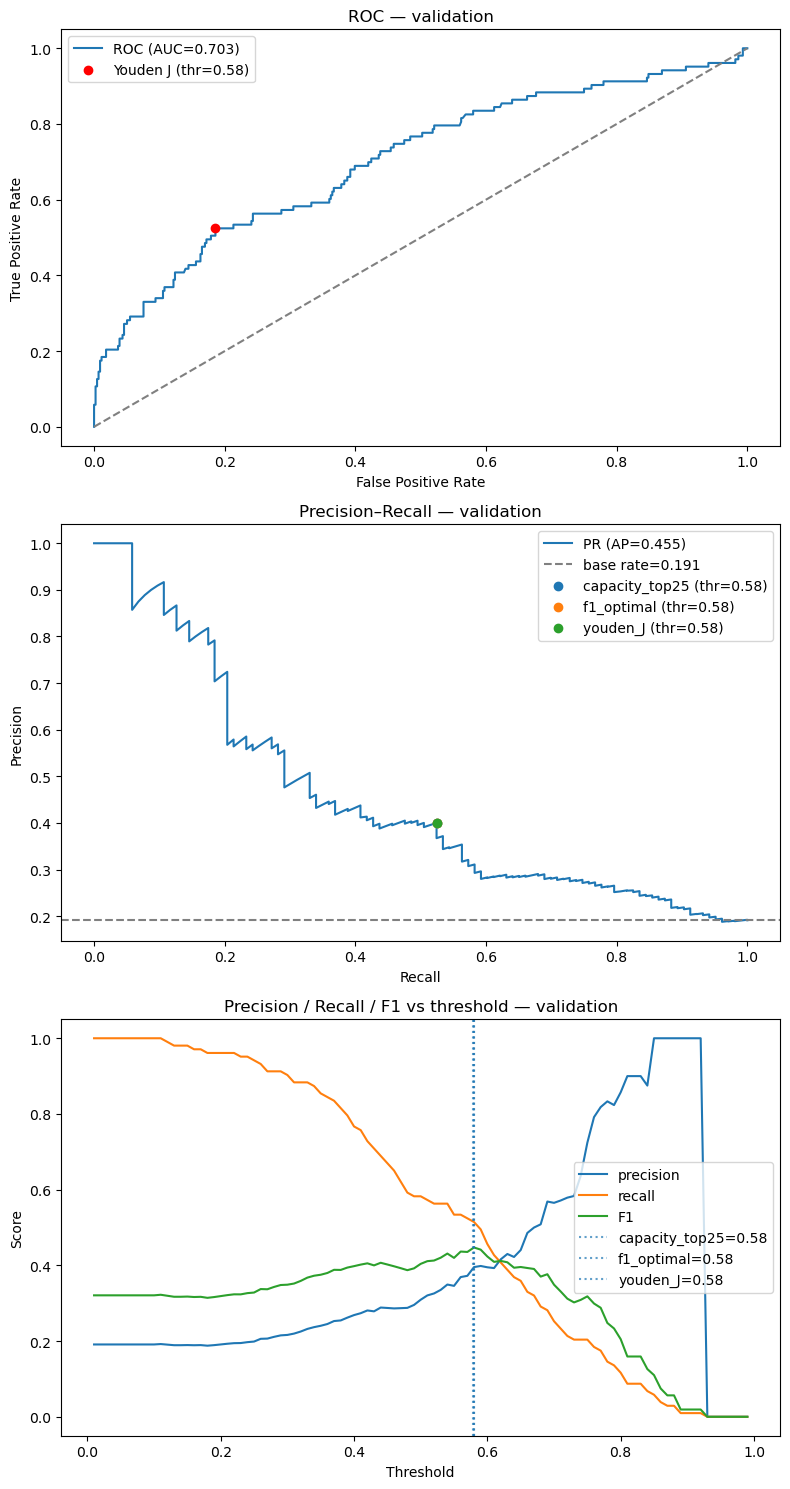

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve

# Model whose scores we threshold-tune (defaults to the tuned XGBoost above;
score_model = xgb_best_pipe

val_s  = score_model.predict_proba(X_val)[:, 1]
test_s = score_model.predict_proba(X_test)[:, 1]

# ---- Curves (validation) ----------------------------------------------------
fpr, tpr, roc_thr = roc_curve(y_val, val_s)
prec, rec, pr_thr = precision_recall_curve(y_val, val_s)
roc_auc = roc_auc_score(y_val, val_s)
pr_auc  = average_precision_score(y_val, val_s)

# ---- Candidate thresholds (all chosen on validation) ------------------------
thr_capacity = float(np.quantile(val_s, 0.75))          # top-25% volume (the constraint)
f1_curve     = 2 * prec * rec / (prec + rec + 1e-12)
thr_f1       = float(pr_thr[np.argmax(f1_curve[:-1])])  # last point has no threshold
thr_youden   = float(roc_thr[np.argmax(tpr - fpr)])     # max TPR-FPR
CANDIDATES = {'capacity_top25': thr_capacity, 'f1_optimal': thr_f1, 'youden_J': thr_youden}


def _at(scores, y, thr):
    pred = (scores >= thr).astype(int)
    return (100 * pred.mean(), precision_score(y, pred, zero_division=0),
            recall_score(y, pred), f1_score(y, pred))


thr_table = pd.DataFrame([
    {'rule': n, 'threshold': round(t, 3),
     'val_flag%':  round(_at(val_s,  y_val,  t)[0], 1), 'val_prec': round(_at(val_s,  y_val,  t)[1], 3),
     'val_rec':    round(_at(val_s,  y_val,  t)[2], 3), 'val_f1':   round(_at(val_s,  y_val,  t)[3], 3),
     'test_flag%': round(_at(test_s, y_test, t)[0], 1), 'test_prec':round(_at(test_s, y_test, t)[1], 3),
     'test_rec':   round(_at(test_s, y_test, t)[2], 3), 'test_f1':  round(_at(test_s, y_test, t)[3], 3)}
    for n, t in CANDIDATES.items()
])
print(f'VAL  ROC-AUC={roc_auc:.3f}   PR-AUC={pr_auc:.3f}\n')
print(thr_table.to_string(index=False))

# ---- Plots: ROC | PR | precision/recall/F1 vs threshold (stacked) -----------
grid = np.linspace(0.01, 0.99, 99)
sweep = np.array([_at(val_s, y_val, g)[1:] for g in grid])  # prec, rec, f1

fig, ax = plt.subplots(3, 1, figsize=(8, 15))

ax[0].plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.3f})')
ax[0].plot([0, 1], [0, 1], '--', color='grey')
_j = np.argmax(tpr - fpr)
ax[0].scatter(fpr[_j], tpr[_j], color='red', zorder=5, label=f"Youden J (thr={thr_youden:.2f})")
ax[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC — validation')
ax[0].legend()

ax[1].plot(rec, prec, label=f'PR (AP={pr_auc:.3f})')
ax[1].axhline(y_val.mean(), ls='--', color='grey', label=f'base rate={y_val.mean():.3f}')
for n, t in CANDIDATES.items():
    r, p = _at(val_s, y_val, t)[2], _at(val_s, y_val, t)[1]
    ax[1].scatter(r, p, zorder=5, label=f'{n} (thr={t:.2f})')
ax[1].set(xlabel='Recall', ylabel='Precision', title='Precision–Recall — validation')
ax[1].legend()

ax[2].plot(grid, sweep[:, 0], label='precision')
ax[2].plot(grid, sweep[:, 1], label='recall')
ax[2].plot(grid, sweep[:, 2], label='F1')
for n, t in CANDIDATES.items():
    ax[2].axvline(t, ls=':', alpha=0.7, label=f'{n}={t:.2f}')
ax[2].set(xlabel='Threshold', ylabel='Score', title='Precision / Recall / F1 vs threshold — validation')
ax[2].legend()

plt.tight_layout(); plt.show()

In [13]:
# ---- Evaluate model on test set --------------------------------------------
# The tuned XGBoost pipeline is the deployed model. Fix the operating point on
# VALIDATION (top-25% cutoff = 75th percentile of val scores), then report the
# LOCKED test set. Also exports final_model / THRESHOLD / val_scores for the
# risk-tier + current-claim scoring cells below.
final_model = xgb_best_pipe
best_name   = 'xgb'

val_scores = final_model.predict_proba(X_val)[:, 1]
THRESHOLD  = float(np.quantile(val_scores, 0.75))   # flags the riskiest 25% by volume

# Score the locked test set.
test_scores = final_model.predict_proba(X_test)[:, 1]
test_pred   = (test_scores >= THRESHOLD).astype(int)
cap         = capture_at_top_k(y_test, test_scores, 0.25)

summary = pd.Series({
    'model':          best_name,
    'threshold':      round(THRESHOLD, 4),
    'recall@25%':     round(cap['recall_at_25'], 3),      # headline: denial capture
    'precision@25%':  round(cap['precision_at_25'], 3),
    'pr_auc':         round(average_precision_score(y_test, test_scores), 3),
    'roc_auc':        round(roc_auc_score(y_test, test_scores), 3),
    'precision@thr':  round(precision_score(y_test, test_pred, zero_division=0), 3),
    'recall@thr':     round(recall_score(y_test, test_pred), 3),
    'f1@thr':         round(f1_score(y_test, test_pred), 3),
})
print(f'=== TEST metrics ({best_name}) ===')
print(summary.to_string())
print('\nConfusion matrix [tn fp / fn tp]:')
print(confusion_matrix(y_test, test_pred))

=== TEST metrics (xgb) ===
model               xgb
threshold        0.5789
recall@25%        0.457
precision@25%     0.474
pr_auc            0.484
roc_auc           0.684
precision@thr     0.462
recall@thr        0.471
f1@thr            0.466

Confusion matrix [tn fp / fn tp]:
[[322  77]
 [ 74  66]]


## 6. Risk tiers

| Tier | Rule |
|------|------|
| **High** | prob ≥ top-25% threshold (the reviewed slice) |
| **Medium** | top-25% threshold > prob ≥ median |
| **Low** | prob < median |

In [14]:
MEDIAN_CUT = float(np.quantile(val_scores, 0.50))

def to_tier(p):
    if p >= THRESHOLD:
        return 'High'
    if p >= MEDIAN_CUT:
        return 'Medium'
    return 'Low'

print(f'High  : prob >= {THRESHOLD:.3f}')
print(f'Medium: {MEDIAN_CUT:.3f} <= prob < {THRESHOLD:.3f}')
print(f'Low   : prob < {MEDIAN_CUT:.3f}')

High  : prob >= 0.579
Medium: 0.418 <= prob < 0.579
Low   : prob < 0.418


# Part 2 — SHAP explanations for the top-10 riskiest current claims

In [15]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


SHAP values: (500, 36) | base (log-odds): 0.007

Top-10 riskiest current claims:
  claim_id  denial_prob risk_tier
CCLM-00285     0.857737      High
CCLM-00062     0.849613      High
CCLM-00352     0.844053      High
CCLM-00013     0.832461      High
CCLM-00087     0.831528      High
CCLM-00028     0.827521      High
CCLM-00280     0.813950      High
CCLM-00416     0.813412      High
CCLM-00135     0.805310      High
CCLM-00372     0.803898      High


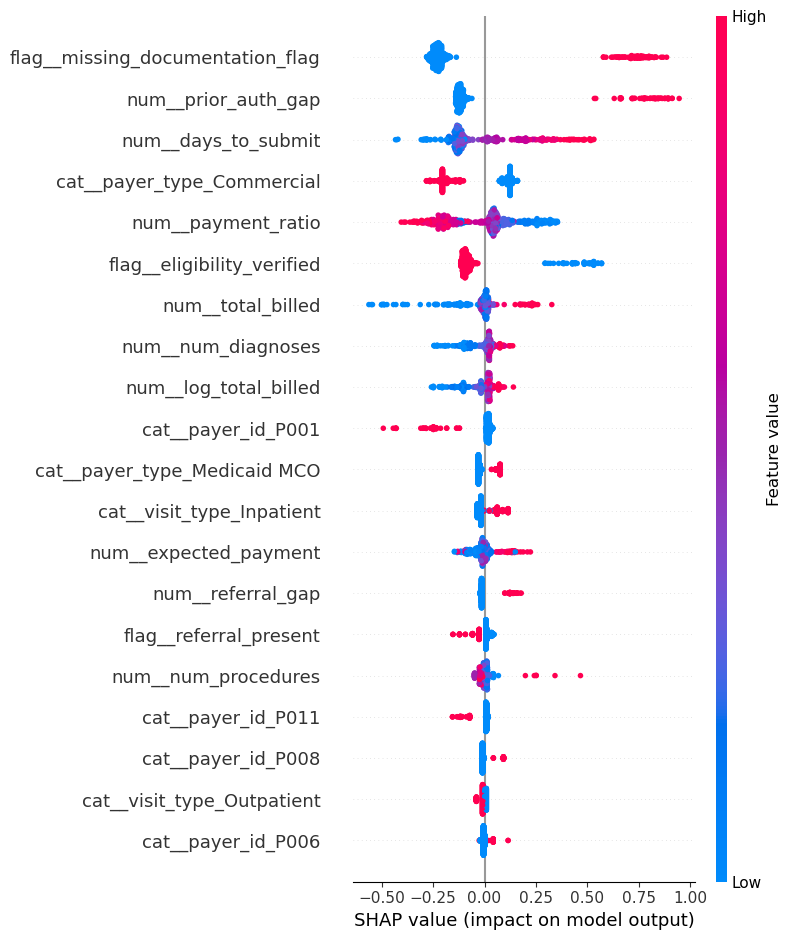

In [16]:
import shap

# ---- Pull the two pipeline stages apart -------------------------------------
prep = final_model.named_steps['prep']   # fitted ColumnTransformer
clf  = final_model.named_steps['clf']    # fitted XGBClassifier

# Transformed feature names, in the exact order the ColumnTransformer emits them
# (cat one-hot -> num scaled -> passthrough flags).
feat_names = list(prep.get_feature_names_out())


def _dense(X):
    return X.toarray() if hasattr(X, 'toarray') else np.asarray(X)


# ---- Score the current claims + assign risk tiers ---------------------------
curr_X      = curr_e[FEATURES]
curr_scores = final_model.predict_proba(curr_X)[:, 1]

ranked = (curr_e[[ID_COL]]
          .assign(denial_prob=curr_scores,
                  risk_tier=[to_tier(p) for p in curr_scores])
          .sort_values('denial_prob', ascending=False))

# Positional indices (into curr_X) of the 10 highest-risk claims.
top_pos = np.argsort(curr_scores)[::-1][:10]

# ---- SHAP: exact TreeExplainer on the fitted booster (transformed space) ----
explainer  = shap.TreeExplainer(clf)
Xt_all     = _dense(prep.transform(curr_X))
sv_all     = explainer.shap_values(Xt_all)
if isinstance(sv_all, list):          # some shap versions return [neg, pos]
    sv_all = sv_all[1]
base_value = float(np.ravel(explainer.expected_value)[-1])

print('SHAP values:', sv_all.shape, '| base (log-odds):', round(base_value, 3))
print('\nTop-10 riskiest current claims:')
print(ranked.head(10).to_string(index=False))

# Global view: which features drive denial risk across all current claims.
shap.summary_plot(sv_all, Xt_all, feature_names=feat_names, show=True)

=== Plain-English SHAP explanations — top-10 riskiest current claims ===

Claim CCLM-00285 — denial risk 86% (High tier)
  Raises risk:  prior_auth_gap = 1 (+0.86); missing_documentation_flag = 1 (+0.73); total_billed = 71,797.00 (+0.26)
  Lowers risk:  days_to_submit = 13 (-0.14); payer_type = Commercial (-0.12)

Claim CCLM-00062 — denial risk 85% (High tier)
  Raises risk:  prior_auth_gap = 1 (+0.88); eligibility_verified = 0 (+0.55); payment_ratio = 0.33 (+0.34)
  Lowers risk:  missing_documentation_flag = 0 (-0.19); num_diagnoses = 3 (-0.06)

Claim CCLM-00352 — denial risk 84% (High tier)
  Raises risk:  prior_auth_gap = 1 (+0.89); missing_documentation_flag = 1 (+0.65); payment_ratio = 0.31 (+0.34)
  Lowers risk:  days_to_submit = 10 (-0.17); eligibility_verified = 1 (-0.09)

Claim CCLM-00013 — denial risk 83% (High tier)
  Raises risk:  prior_auth_gap = 1 (+0.95); eligibility_verified = 0 (+0.43); payment_ratio = 0.32 (+0.35)
  Lowers risk:  missing_documentation_flag = 0 (-0.18)

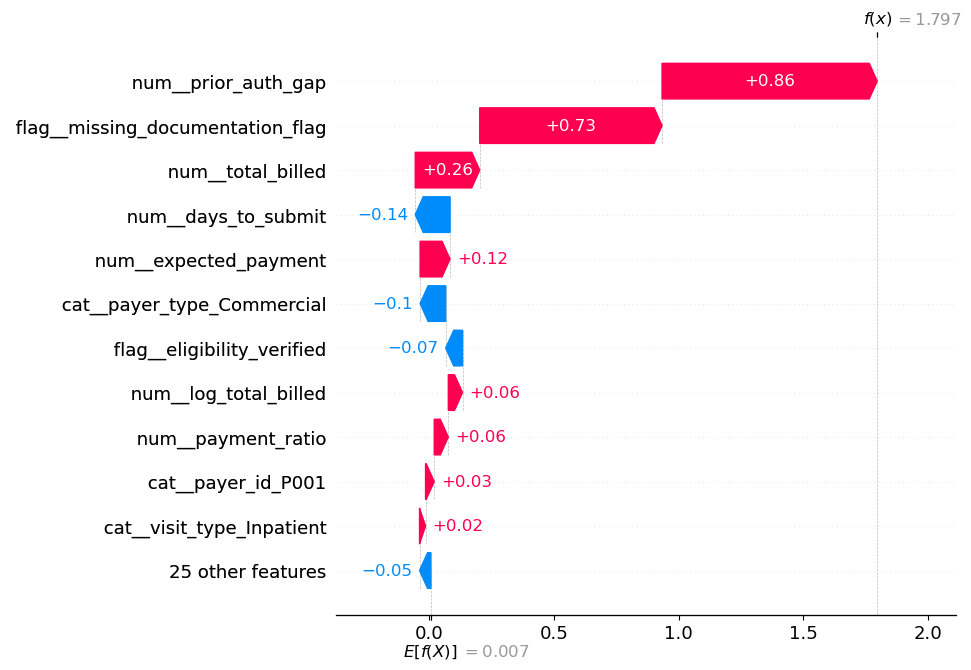

In [18]:
# ---- Map each transformed column back to its ORIGINAL feature ---------------
def to_orig(feat):
    if feat.startswith('cat__'):
        rest = feat[len('cat__'):]
        for col in CATEGORICAL:                       # longest known prefix wins
            if rest.startswith(col + '_'):
                return col
        return rest
    for pfx in ('num__', 'flag__', 'remainder__'):
        if feat.startswith(pfx):
            return feat[len(pfx):]
    return feat

orig_of = np.array([to_orig(f) for f in feat_names])

# Human-readable "field = value" using the RAW (un-scaled) current-claim row.
INT_COLS = set(BINARY_FLAGS) | {'prior_auth_gap', 'referral_gap',
                                'num_procedures', 'num_diagnoses', 'days_to_submit'}

def fmt(col, row):
    v = row[col]
    if col in CATEGORICAL:
        return f"{col} = {v}"
    if col in INT_COLS:
        return f"{col} = {int(v)}"
    return f"{col} = {v:,.2f}"


def explain_claim(pos, n_up=3, n_down=2):
    """Plain-English SHAP explanation for one current claim (positional index)."""
    row  = curr_e.iloc[pos]
    sv   = sv_all[pos]
    # Aggregate one-hot contributions back to the original feature.
    agg = {}
    for feat, val in zip(orig_of, sv):
        agg[feat] = agg.get(feat, 0.0) + val
    drivers = sorted(agg.items(), key=lambda kv: kv[1], reverse=True)

    up   = [(f, s) for f, s in drivers if s > 0][:n_up]
    down = [(f, s) for f, s in drivers if s < 0][-n_down:][::-1]

    prob = float(final_model.predict_proba(curr_X.iloc[[pos]])[:, 1][0])
    lines = [f"Claim {row[ID_COL]} — denial risk {prob:.0%} "
             f"({to_tier(prob)} tier)"]
    lines.append("  Raises risk:  " + "; ".join(
        f"{fmt(f, row)} ({s:+.2f})" for f, s in up))
    if down:
        lines.append("  Lowers risk:  " + "; ".join(
            f"{fmt(f, row)} ({s:+.2f})" for f, s in down))
    return "\n".join(lines)


print("=== Plain-English SHAP explanations — top-10 riskiest current claims ===\n")
explanations = []
for pos in top_pos:
    text = explain_claim(pos)
    explanations.append({ID_COL: curr_e.iloc[pos][ID_COL],
                         'denial_prob': float(curr_scores[pos]),
                         'explanation': text})
    print(text)
    print()

# Persist the explanations. Use the stdlib csv writer instead of pandas.to_csv:
# this environment's pandas is mixed-version (to_csv imports SequenceNotStr,
# which only exists in newer pandas), so pd.to_csv raises ImportError here.
import csv
_out = root_path / 'top10_shap_explanations.csv'
with open(_out, 'w', newline='', encoding='utf-8') as _f:
    _w = csv.DictWriter(_f, fieldnames=[ID_COL, 'denial_prob', 'explanation'])
    _w.writeheader()
    _w.writerows(explanations)
print(f'Saved {len(explanations)} explanations -> {_out}')

# Detailed waterfall for the single riskiest claim (transformed columns, so each
# one-hot bar is unambiguous; the printed text above is the aggregated view).
top1 = int(top_pos[0])
shap.plots._waterfall.waterfall_legacy(
    base_value, sv_all[top1],
    features=Xt_all[top1], feature_names=feat_names,
    max_display=12, show=True)

## Explain a single claim by `claim_id`

`sv_all` holds SHAP values for **every** current claim, so any `claim_id` can be
explained on demand — not only the top-10. `explain_by_id` looks up the row,
reuses the same aggregation, and optionally shows the waterfall for that claim.

Claim CCLM-00285 — denial risk 86% (High tier)
  Raises risk:  prior_auth_gap = 1 (+0.86); missing_documentation_flag = 1 (+0.73); total_billed = 71,797.00 (+0.26)
  Lowers risk:  days_to_submit = 13 (-0.14); payer_type = Commercial (-0.12)


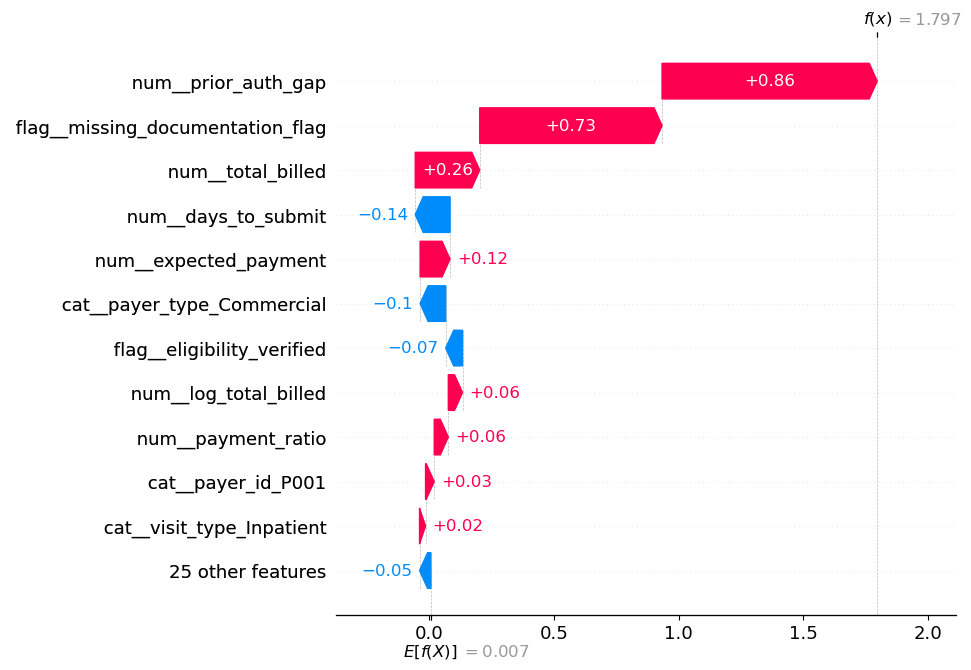

In [19]:
# Positional lookup from claim_id -> row position (into curr_X / sv_all).
_id_to_pos = {cid: i for i, cid in enumerate(curr_e[ID_COL].to_numpy())}


def explain_by_id(claim_id, n_up=3, n_down=2, show_waterfall=True):
    """Plain-English SHAP explanation for a specific current claim_id."""
    if claim_id not in _id_to_pos:
        raise KeyError(f"claim_id {claim_id!r} not found in current_claims")
    pos = _id_to_pos[claim_id]
    print(explain_claim(pos, n_up=n_up, n_down=n_down))
    if show_waterfall:
        shap.plots._waterfall.waterfall_legacy(
            base_value, sv_all[pos],
            features=Xt_all[pos], feature_names=feat_names,
            max_display=12, show=True)
    return explain_claim(pos, n_up=n_up, n_down=n_down)


# ---- Example: change this to any claim_id in current_claims ------------------
CLAIM_ID = curr_e[ID_COL].iloc[int(top_pos[0])]   # defaults to the riskiest claim
_ = explain_by_id(CLAIM_ID)

## 7. Persist artifacts for the scoring notebook


In [20]:
# ---- Persist model + explainability artifacts ------------------------------
import joblib

art_path = root_path / 'artifacts'
art_path.mkdir(exist_ok=True)

# 1) The deployed model object (preprocessor + XGBoost pipeline).
joblib.dump(final_model, art_path / 'model.joblib')

# 2) The explainability object (SHAP TreeExplainer). If it can't be pickled on
#    this environment, the scoring notebook rebuilds it from the model's booster.
try:
    joblib.dump(explainer, art_path / 'shap_explainer.joblib')
    _expl_saved = True
except Exception as e:
    _expl_saved = False
    print('Could not pickle explainer (scoring notebook will rebuild it):', e)

# 3) Operating-point + schema metadata needed to reproduce scoring exactly.
joblib.dump({
    'THRESHOLD': THRESHOLD, 'MEDIAN_CUT': MEDIAN_CUT, 'base_value': base_value,
    'feat_names': feat_names, 'FEATURES': FEATURES,
    'CATEGORICAL': CATEGORICAL, 'BINARY_FLAGS': BINARY_FLAGS,
    'NUMERIC': NUMERIC, 'ENGINEERED': ENGINEERED,
}, art_path / 'metadata.joblib')

print('Saved artifacts ->', art_path)
print('  - model.joblib')
print('  - metadata.joblib')
if _expl_saved:
    print('  - shap_explainer.joblib')

Saved artifacts -> C:\Users\shiva\Desktop\Ensemble_Partner_Hiring_Assignment\Hiring Assessment - AI Team - Classical ML + Gen AI problem (ML + basic Gen AI) (1)\Hiring Assessment - AI Team - Classical ML + Gen AI problem\artifacts
  - model.joblib
  - metadata.joblib
  - shap_explainer.joblib
